# Project 1: Data Collection and Initial Analysis of Stock Market Data



In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

## 1. Load the Data


In [7]:
# Set the path to the ZIP file
zip_path = 'Daily Historical Stock Prices (1970 - 2018).zip'

# Set the ZIP file path
zip_path = 'Daily Historical Stock Prices (1970 - 2018).zip'

# Load the datasets from the ZIP file
with zipfile.ZipFile(zip_path) as z:
    stocks = pd.read_csv(z.open('historical_stocks.csv'))
    prices = pd.read_csv(z.open('historical_stock_prices.csv'), nrows=1500000)

# Display basic information
print("Prices shape:", prices.shape)
print("Stocks shape:", stocks.shape)

display(prices.head())
display(stocks.head())

Prices shape: (1500000, 8)
Stocks shape: (6460, 5)


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


**Observation:** The stock price dataset contains daily trading information such as open, close, low, high, adjusted close, volume, ticker, and date. The stock information dataset contains ticker-level company details such as exchange, name, sector, and industry.

In [8]:
# Display column names and data types

print("Price columns:")
print(prices.columns)

print("\nPrice data types:")
print(prices.dtypes)

print("\nStock columns:")
print(stocks.columns)

print("\nStock data types:")
print(stocks.dtypes)

Price columns:
Index(['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume',
       'date'],
      dtype='object')

Price data types:
ticker        object
open         float64
close        float64
adj_close    float64
low          float64
high         float64
volume         int64
date          object
dtype: object

Stock columns:
Index(['ticker', 'exchange', 'name', 'sector', 'industry'], dtype='object')

Stock data types:
ticker      object
exchange    object
name        object
sector      object
industry    object
dtype: object


## 2. Data Cleaning

In [9]:
# Check missing values
print('Missing values in prices:')
display(prices.isnull().sum())

print('Missing values in stocks:')
display(stocks.isnull().sum())

Missing values in prices:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


Missing values in stocks:


,0
ticker,0
exchange,0
name,0
sector,1440
industry,1440


In [10]:
# Check and remove duplicate rows
print('Duplicate rows in prices before cleaning:', prices.duplicated().sum())
print('Duplicate rows in stocks before cleaning:', stocks.duplicated().sum())

prices = prices.drop_duplicates()
stocks = stocks.drop_duplicates()

print('Duplicate rows in prices after cleaning:', prices.duplicated().sum())
print('Duplicate rows in stocks after cleaning:', stocks.duplicated().sum())

Duplicate rows in prices before cleaning: 0
Duplicate rows in stocks before cleaning: 0
Duplicate rows in prices after cleaning: 0
Duplicate rows in stocks after cleaning: 0


In [11]:
# Convert date column to datetime format
prices['date'] = pd.to_datetime(prices['date'], errors='coerce')

# Drop rows where date could not be converted
prices = prices.dropna(subset=['date'])

print(prices['date'].min())
print(prices['date'].max())
print(prices.dtypes)

1972-06-01 00:00:00
2018-08-24 00:00:00
ticker               object
open                float64
close               float64
adj_close           float64
low                 float64
high                float64
volume                int64
date         datetime64[ns]
dtype: object


**Observation:** Converting the date field into datetime format is important because it allows time-series analysis, monthly grouping, and decade segmentation.

## 3. Data Segmentation by Decade

In [12]:
# Create decade and month columns
prices['decade'] = (prices['date'].dt.year // 10) * 10
prices['month'] = prices['date'].dt.to_period('M').dt.to_timestamp()

# Display number of records by decade
decade_counts = prices['decade'].value_counts().sort_index()
display(decade_counts)

,count
decade,
1970,4683
1980,115500
1990,244186
2000,464638
2010,670993


**Observation:** Segmenting the data by decade makes it easier to compare long-term changes in prices, trading volume, and volatility across different market periods.

## 4. Merge the Datasets

In [13]:
# Merge daily prices with stock details using ticker
merged = prices.merge(stocks, on='ticker', how='left')

print('Merged dataset shape:', merged.shape)
display(merged.head())

Merged dataset shape: (1500000, 14)


,ticker,open,close,adj_close,low,high,volume,date,decade,month,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08,2010,2013-05-01,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09,2010,2013-05-01,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10,2010,2013-05-01,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13,2010,2013-05-01,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14,2010,2013-05-01,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


**Observation:** The merged dataset adds company, sector, exchange, and industry information to each price record. This makes sector-level analysis possible.

## 5. Summary Statistics

In [14]:
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
summary_by_decade = prices.groupby('decade')[numeric_cols].agg(['mean', 'median', 'std']).round(2)
display(summary_by_decade)

open                     high                      low         \
          mean median       std    mean median       std    mean median   
decade                                                                    
1970      1.48   0.65      2.47    1.51   0.66      2.50    1.46   0.64   
1980     26.77   4.47   1993.23   27.23   4.53   2026.36   26.36   4.43   
1990     57.69   9.63   2195.46   59.52   9.78   2282.34   55.88   9.50   
2000    763.21  15.48  14551.13  780.62  15.74  14882.67  747.05  15.20   
2010     37.64  19.79     97.08   38.12  20.05     99.35   37.12  19.50   

                   close                       volume                         
             std    mean median       std        mean    median          std  
decade                                                                        
1970        2.43    1.48   0.65      2.47  1240756.32  315245.0   1799873.07  
1980     1956.23   26.88   4.47   2000.37  1387847.52   64000.0   7796740.29  
1990     2115.88   57.67   9.64   2198.37  1706709.28   67300.0  11549329.61  
2000    14281.31  764.37  15.48  14611.46  3773306.39  140800.0  28509803.47  
2010       93.68   37.62  19.79     96.28  3763608.84  143400.0  63751947.80

**Observation:** The summary table compares the average, middle value, and variability of stock prices and trading volume by decade. Higher standard deviation indicates greater variation and possible volatility.

## 6. Visualization 1: Average Monthly Closing Price

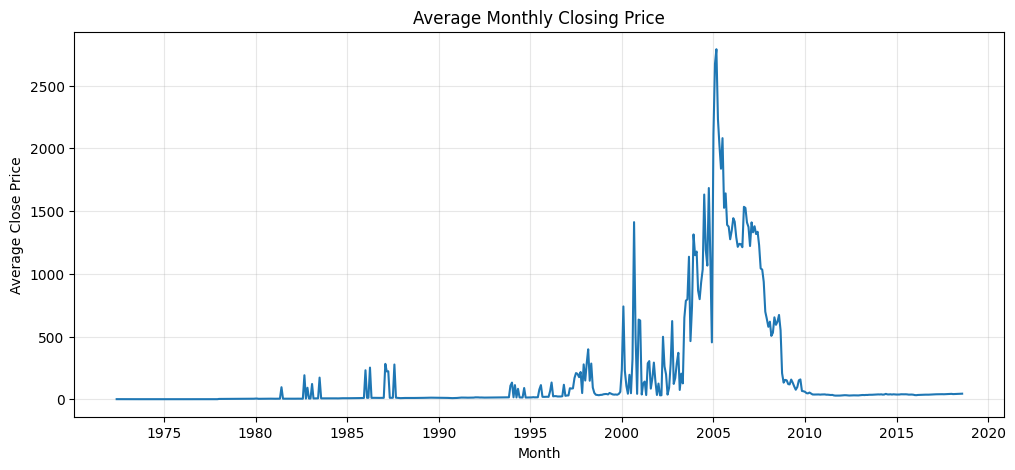

In [15]:
monthly_close = prices.groupby('month')['close'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_close['month'], monthly_close['close'])
plt.title('Average Monthly Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The time-series chart shows how average closing prices changed over time. In general, the analysis helps identify long-term movements, periods of growth, and periods where market prices were more unstable.

## 7. Visualization 2: Trading Volume Histogram

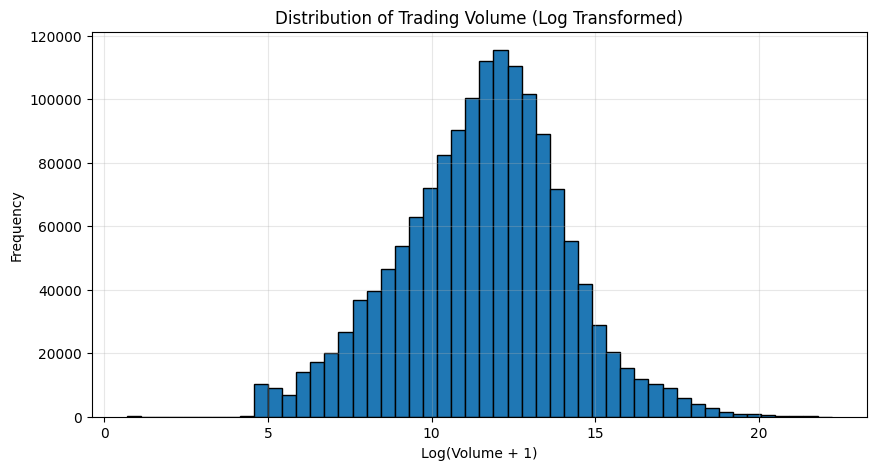

In [20]:
# Distribution of Trading Volume

plt.figure(figsize=(10,5))

# Apply log transformation
log_volume = np.log1p(prices['volume'])

plt.hist(log_volume, bins=50, edgecolor='black')

plt.title('Distribution of Trading Volume (Log Transformed)')
plt.xlabel('Log(Volume + 1)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.show()

**Observation:** Trading volume is usually right-skewed, meaning most daily trading volumes are relatively low while a smaller number of observations have extremely high volume. These high-volume days may reflect major news, market events, or strong investor activity.

## 8. Visualization 3: High and Low Price Boxplots

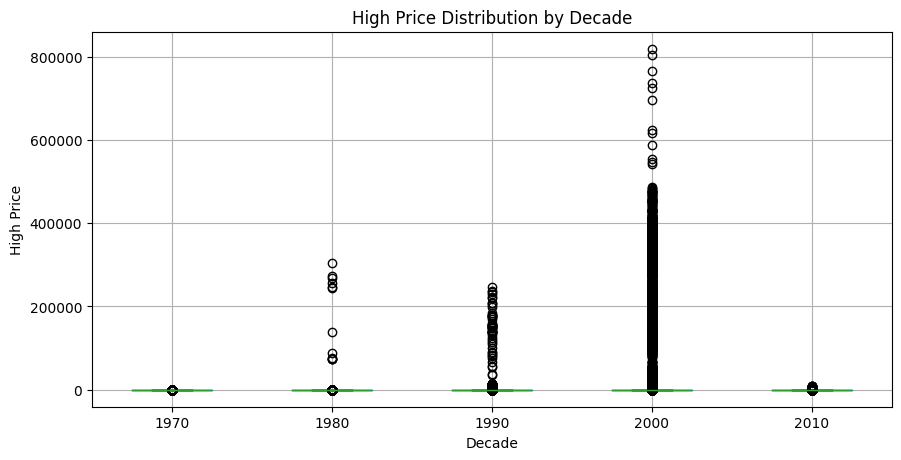

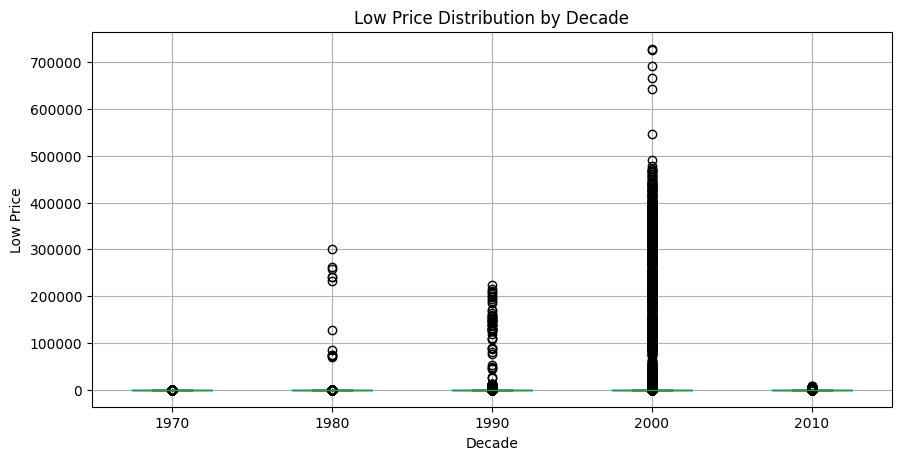

In [17]:
prices.boxplot(column='high', by='decade', figsize=(10, 5))
plt.title('High Price Distribution by Decade')
plt.suptitle('')
plt.xlabel('Decade')
plt.ylabel('High Price')
plt.show()

prices.boxplot(column='low', by='decade', figsize=(10, 5))
plt.title('Low Price Distribution by Decade')
plt.suptitle('')
plt.xlabel('Decade')
plt.ylabel('Low Price')
plt.show()

**Observation:** The boxplots show the spread of high and low prices by decade. Wider boxes and more outliers indicate greater price variation and possible volatility.

## 9. Sector Analysis

In [18]:
sector_summary = merged.groupby('sector').agg(
    avg_close=('close', 'mean'),
    avg_volume=('volume', 'mean'),
    records=('ticker', 'count')
).sort_values('records', ascending=False).round(2)

display(sector_summary.head(10))

,avg_close,avg_volume,records
sector,,,
FINANCE,48.80,786241.89,295592
TECHNOLOGY,22.35,5236665.99,226385
CONSUMER SERVICES,37.39,1349897.42,212773
HEALTH CARE,248.88,1713322.87,139337
CAPITAL GOODS,20.32,473516.41,84666
CONSUMER DURABLES,24.98,199411.16,80316
BASIC INDUSTRIES,40.25,1513768.45,78877
CONSUMER NON-DURABLES,22.37,413827.46,54905
ENERGY,25.51,1107195.14,48960


**Observation:** Sector analysis provides more context because different industries may behave differently. Sectors with many records are more strongly represented in the dataset.

## 10. Comparative Analysis

Across decades, the data can be compared using price level, volume, and volatility. The closing price trend provides a general view of long-term market performance, while the histogram and boxplots show distribution and spread. Volume is important because it reflects the level of trading activity and investor participation.

## 11. Possible Hypotheses

1. Average closing prices increase over time as companies grow and markets expand.
2. Trading volume increases in later decades due to electronic trading and higher investor participation.
3. Some sectors experience higher volatility than others because of changes in technology, regulation, and economic cycles.
4. Market events such as recessions or financial crises may create outliers in price and volume.

## 12. Conclusion

This exploratory data analysis examined historical stock prices from 1970 to 2018. The analysis included data loading, cleaning, segmentation by decade, merging with company information, calculating summary statistics, and creating visualizations. The results show that stock data can reveal important long-term trends in price movement, volume, and volatility. The analysis also demonstrates how EDA can support future modeling, forecasting, and investment-related research.